# The Big Project begins!! — "THE PRICE IS RIGHT"

## Week 6 capstone: predict a product's price from its description

This week we build a model that estimates how much something costs, given a text description,
trained on a scrape of Amazon data.

### Order of play
- **DAY 1: Data Curation** ← *we are here*
- DAY 2: Data Pre-processing
- DAY 3: Evaluation, Baselines, Traditional ML
- DAY 4: Deep Learning and LLMs
- DAY 5: Fine-tuning a Frontier Model

### Today — Data Curation
We scrub and curate the dataset. The raw data lives on HuggingFace:
- Dataset: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023
- Per-category product metadata: https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

### 💡 Business value of Data Curation

Data curation is sometimes seen as the unglamorous part of data science — but it's where the real
science happens. R&D on your **dataset** often moves performance more than the fashionable
hyper-parameter tuning we do later. So: prepare for quality time with data quality.

The curation logic lives in a small `pricer/` package next to this notebook:
- `pricer/items.py` — the `Item` data model (+ HuggingFace push/load helpers)
- `pricer/parser.py` — `parse()`: clean one raw datapoint into an `Item` (or drop it)
- `pricer/loaders.py` — `ItemLoader`: download & curate a whole category in parallel

In [1]:
# imports

import os
import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from huggingface_hub import login
from tqdm.notebook import tqdm

# Make the local `pricer` package importable no matter where the notebook is launched from.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    possible = candidate / "lectures" / "week-six"
    if (possible / "pricer").exists():
        sys.path.insert(0, str(possible))
        break

from pricer.items import Item
from pricer.parser import parse

load_dotenv(override=True)

True

### Log in to HuggingFace

You need a (free) HuggingFace account and an access token. Create one at
https://huggingface.co/settings/tokens and put it in your `.env` as `HF_TOKEN=hf_...`.
If you get a *"Note"* about an environment variable being set, ignore it.

In [2]:
hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Load our dataset

We start with a single category — **Appliances** — to explore.

> **Note on loading:** the McAuley dataset ships a *loading script*, which modern `datasets`
> (>= 4) no longer supports (and which trips a pyarrow error). So we read the raw
> `meta_<category>.jsonl` straight from the Hub via `pricer.loaders.fetch_raw_dataset`, which
> returns a plain list of product dicts — same data, no loading script needed.

In [3]:
from pricer.loaders import fetch_raw_dataset

# A list of product dicts for the Appliances category (downloads the raw .jsonl from the Hub).
dataset = fetch_raw_dataset("Appliances")

In [4]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 94,327


Investigate a particular datapoint to see the raw fields we have to work with:

In [5]:
dataset[6]

{'main_category': 'Appliances',
 'title': 'WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003',
 'average_rating': 4.6,
 'rating_number': 323,
 'features': ['【PARTS NUMBER】The WD12X10327 dishwasher top rack wheels and stud assembly Kit （4 pcs）',
  '【SCOPE OF APPLICATION】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud',
  '【REPLACES PART】1811003, AP4980629, WD12X0330, WD12X0356, WD12X0357, WD12X0383, WD12X0385, WD12X10327, WD12X330, WD12X356, WD12X357, WD12X383, WD12X385',
  '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure',
  '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask

In [6]:
# What's the most expensive item?

max_price = 0
max_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint["price"])
        if price > max_price:
            max_item = datapoint
            max_price = price
    except ValueError:
        pass

print(f"The most expensive item is {max_item['title']} and it costs {max_price:,.2f}")

  0%|          | 0/94327 [00:00<?, ?it/s]

The most expensive item is TurboChef BULLET Rapid Cook Electric Microwave Convection Oven and it costs 21,095.62


Looks like it's going at a bargain price!! 😄

https://www.amazon.com/TurboChef-Electric-Countertop-Microwave-Convection/dp/B01D05U9NO/

### Curate with `parse`

`parse` keeps only items in the **\$0.50–\$999.49** range with enough descriptive text
(≥ 600 chars after scrubbing), strips product/model codes and noisy fields, and extracts a weight.
Items that don't qualify come back as `None` and get filtered out.

In [7]:
# Load into Item objects if they have a price range $0.50-$999.49 and enough details
items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

  0%|          | 0/94327 [00:00<?, ?it/s]

There are 35,307 items from 94,327 datapoints


In [8]:
items[0]

<WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003 = $8.99>

`item.full` is the cleaned text the model will learn from:

In [9]:
print(items[0].full)

Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color": "White", "Material Type": "Plastic", "Date First Available": "July 14, 2019", "Brand": "AMI PARTS", "Material": "Plastic", "Model Name": " Rack Roller and stud 

In [10]:
prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

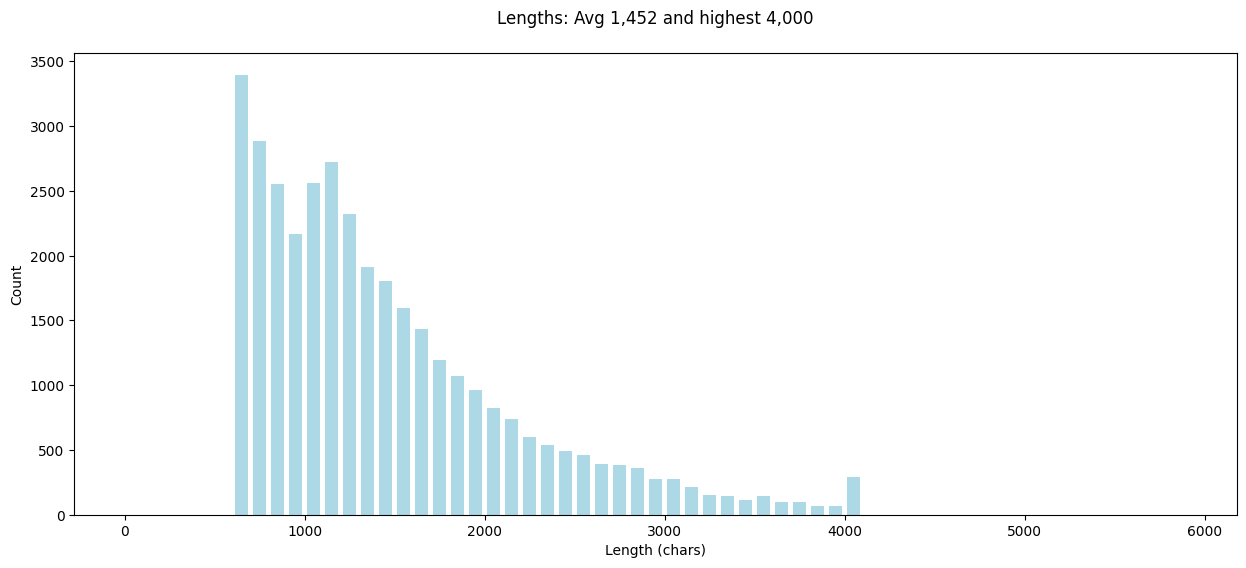

In [11]:
# Plot the distribution of text lengths
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

In [ ]:
max_length = max(lengths)
max_length_item = items[lengths.index(max_length)]
print(max_length_item.full)

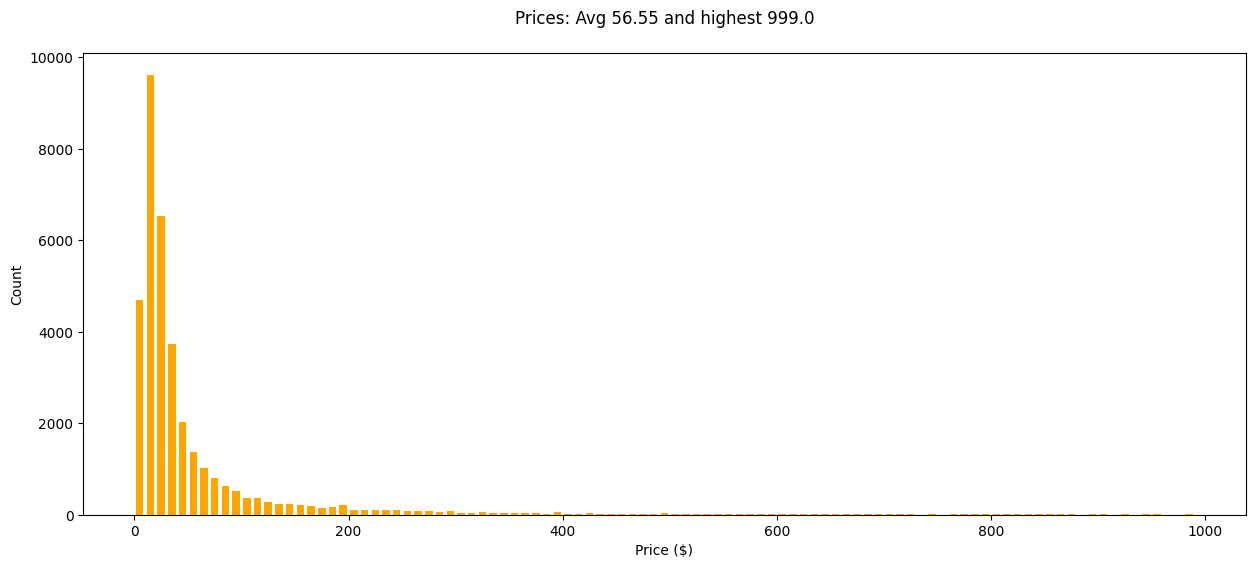

In [12]:
# Plot the distribution of prices
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [13]:
print(items[3].full)

MLGB Stainless Steel Brushed Pattern Dishwasher Magnet Cover Panel Decal Home Appliance Art, Stainless Steel Fridge Door Cover Decals Magnetic, Black, Mobile Magnetic 23" x 26"
['Stainless Steel Brushed Pattern Magnetic Dishwasher Panel Covers allow you to easily transform your kitchen as the seasons change. You can instantly get rid of outdated and/or mismatched appliances, will give your kitchen a refreshing look.', ':', 'Vinyl + rubber magnet', 'Occasion:', 'Magnet Dishwasher Cover Decor dishwasher covers and any metal device surface with magnetism.', '【Kitchen Dishwasher Covers SIZE】S - 23 W x 17 H inches; 58.5 W x 43 H cm;L - 23 W x 26 H inches; 58.5 W x 66 H cm;', 'Attention:', 'Just ensure that your dishwasher is magnetic before ordering the dishwasher cover magnet', 'Due to the inconsistent calibration of the monitor, the colors on the computer monitor may be slightly different.', 'Quality service:', 'If you have any questions or questions, please feel free to contact us and we

## Scaling up — load many categories with `ItemLoader`

`ItemLoader` downloads a whole category from HuggingFace and curates it across CPU processes.

⚠️ **Heads-up:** these steps download large datasets and pin your CPU. The full multi-category load
can take a while and a lot of memory. Pass `workers=1` to `loader.load()` if it's too heavy, or just
load a single category to follow along.

In [14]:
from pricer.loaders import ItemLoader
loader = ItemLoader("Appliances")
items = loader.load()

Loading dataset Appliances


100%|██████████| 95/95 [00:02<00:00, 35.53it/s]


Completed Appliances with 35,307 datapoints in 0.1 mins


In [15]:
dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

In [17]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

Loading dataset Automotive


100%|██████████| 2004/2004 [00:18<00:00, 109.37it/s]


Completed Automotive with 974,469 datapoints in 1.0 mins
Loading dataset Electronics


raw/meta_categories/meta_Electronics.jso(…):   0%|          | 0.00/5.25G [00:00<?, ?B/s]

100%|██████████| 1611/1611 [00:15<00:00, 106.66it/s]


...

100%|██████████| 95/95 [00:01<00:00, 68.33it/s]


Completed Appliances with 35,307 datapoints in 0.1 mins
Loading dataset Musical_Instruments


raw/meta_categories/meta_Musical_Instrum(…):   0%|          | 0.00/632M [00:00<?, ?B/s]

100%|██████████| 214/214 [00:01<00:00, 114.40it/s]


Completed Musical_Instruments with 68,855 datapoints in 0.3 mins


In [18]:
print(f"A grand total of {len(items):,} items")

A grand total of 2,933,577 items


In [19]:
items[1000]

<Coolant Temperature Sensor Compatible with Volvo V70 850 S70 960 C70 S90 V90 1997-1998 = $26.7>

### Deduplicate

Drop items that share a title, then items that share identical full text:

In [20]:
random.seed(42)
random.shuffle(items)

seen = set()
items = [x for x in tqdm(items) if not (x.title in seen or seen.add(x.title))]

seen = set()
items = [x for x in tqdm(items) if not (x.full in seen or seen.add(x.full))]

del seen
print(f"After deduplication, we have {len(items):,} items")

  0%|          | 0/2933577 [00:00<?, ?it/s]

  0%|          | 0/2889429 [00:00<?, ?it/s]

After deduplication, we have 2,887,890 items


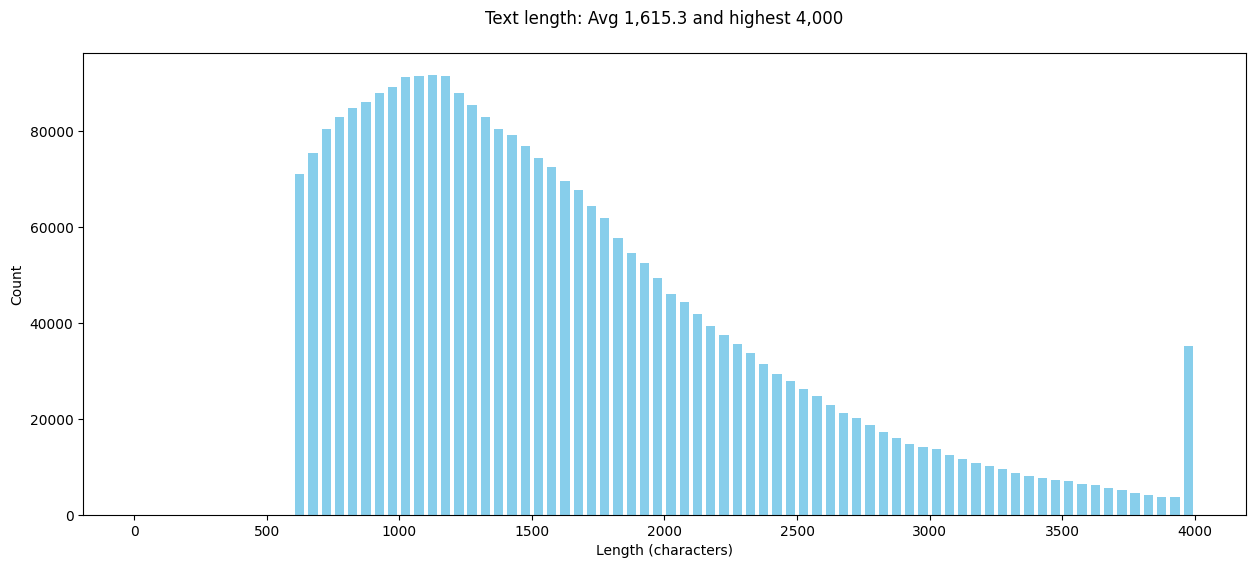

In [21]:
lengths = [len(item.full) for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Text length: Avg {sum(lengths)/len(lengths):,.1f} and highest {max(lengths):,}\n")
plt.xlabel('Length (characters)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="skyblue", bins=range(0, 4050, 50))
plt.show()

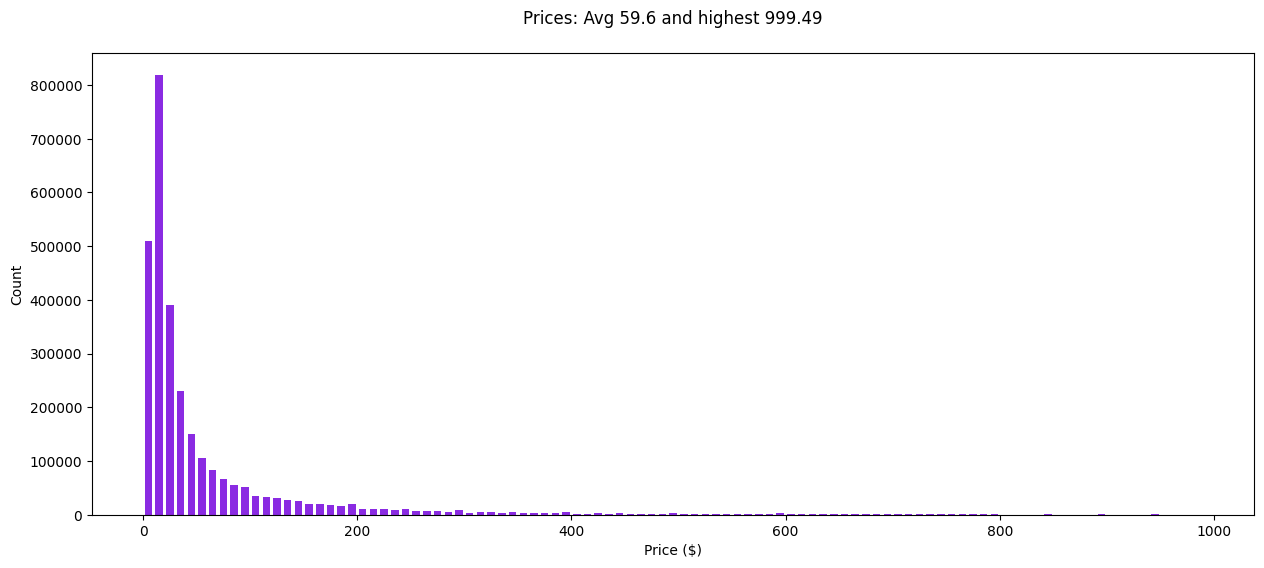

In [22]:
# Plot the distribution of prices
prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

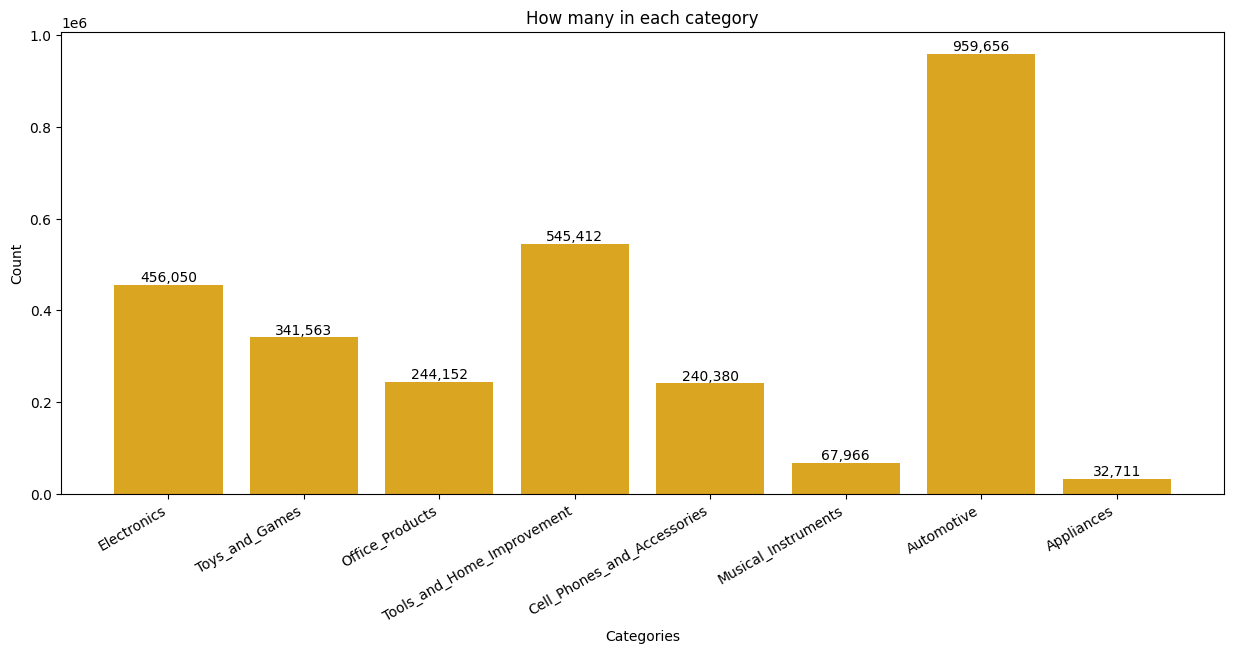

In [23]:
category_counts = Counter([item.category for item in items])
categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')
plt.show()

### Build a balanced sample

The raw data skews toward cheap items and a couple of huge categories (Automotive,
Tools_and_Home_Improvement). We draw a **price- and category-weighted** sample so the final
dataset is less lopsided — favouring pricier items and down-weighting the dominant categories.

In [24]:
np.random.seed(42)

SIZE = 820_000

prices = np.array([it.price for it in items], dtype=float)
categories = np.array([it.category for it in items])
p = (prices - prices.min()) / (prices.max() - prices.min() + 1e-9)

w = p**2
w[categories == "Tools_and_Home_Improvement"] *= 0.5
w[categories == "Automotive"] *= 0.05

w = w / w.sum()
idx = np.random.choice(len(items), size=SIZE, replace=False, p=w)
sample = [items[i] for i in idx]

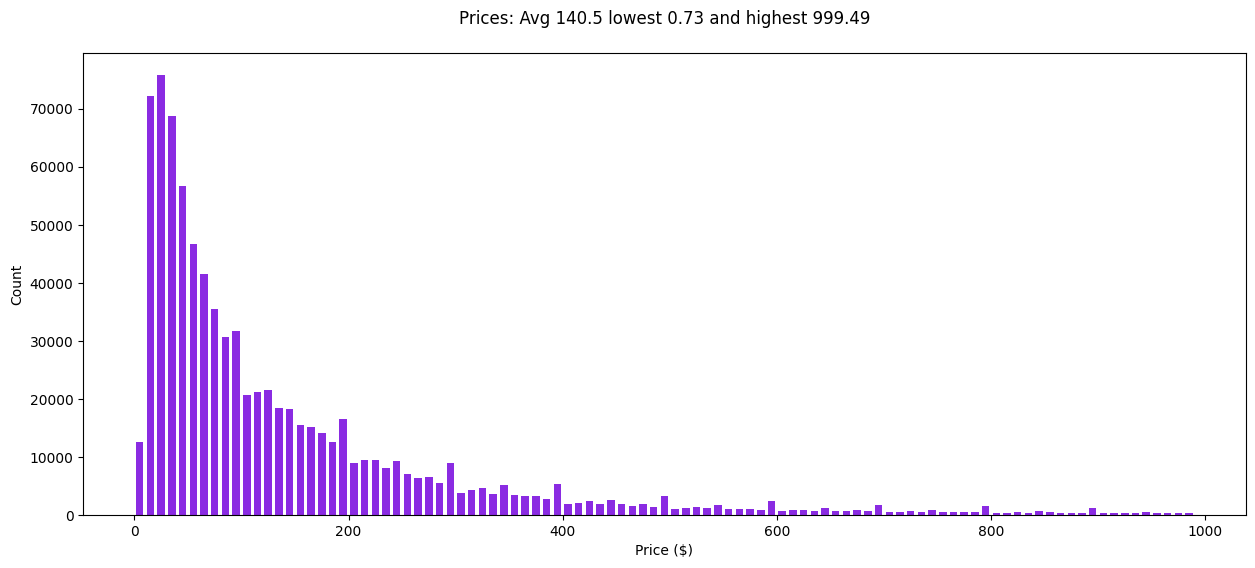

In [25]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

In [26]:
# Shuffle the sample again for the final dataset
random.seed(42)
random.shuffle(sample)

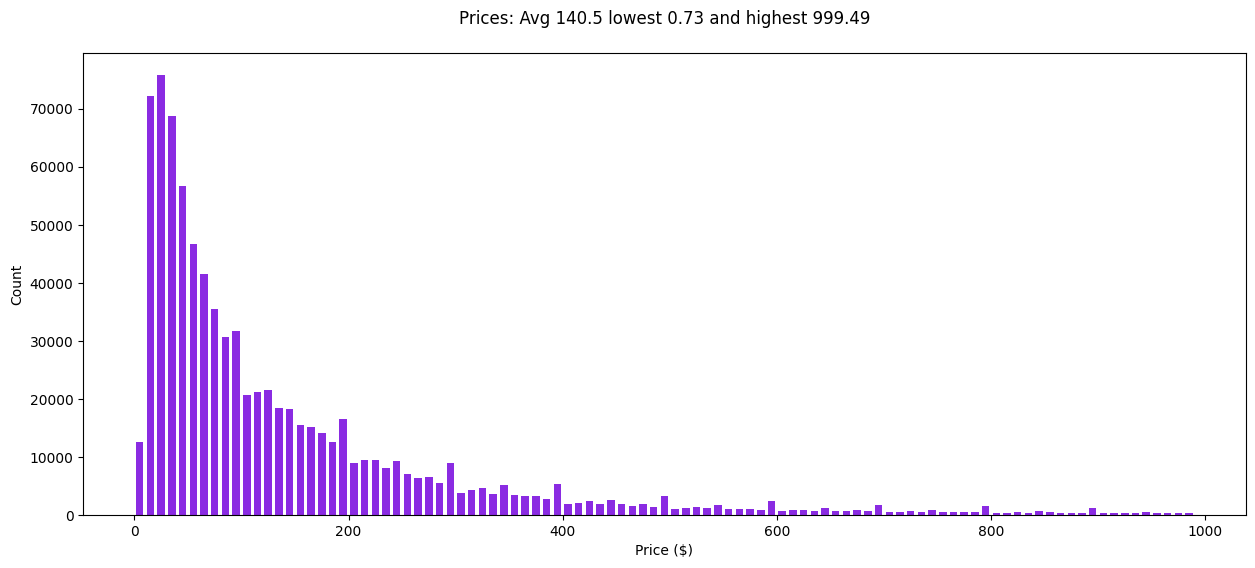

In [27]:
prices = [item.price for item in sample]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

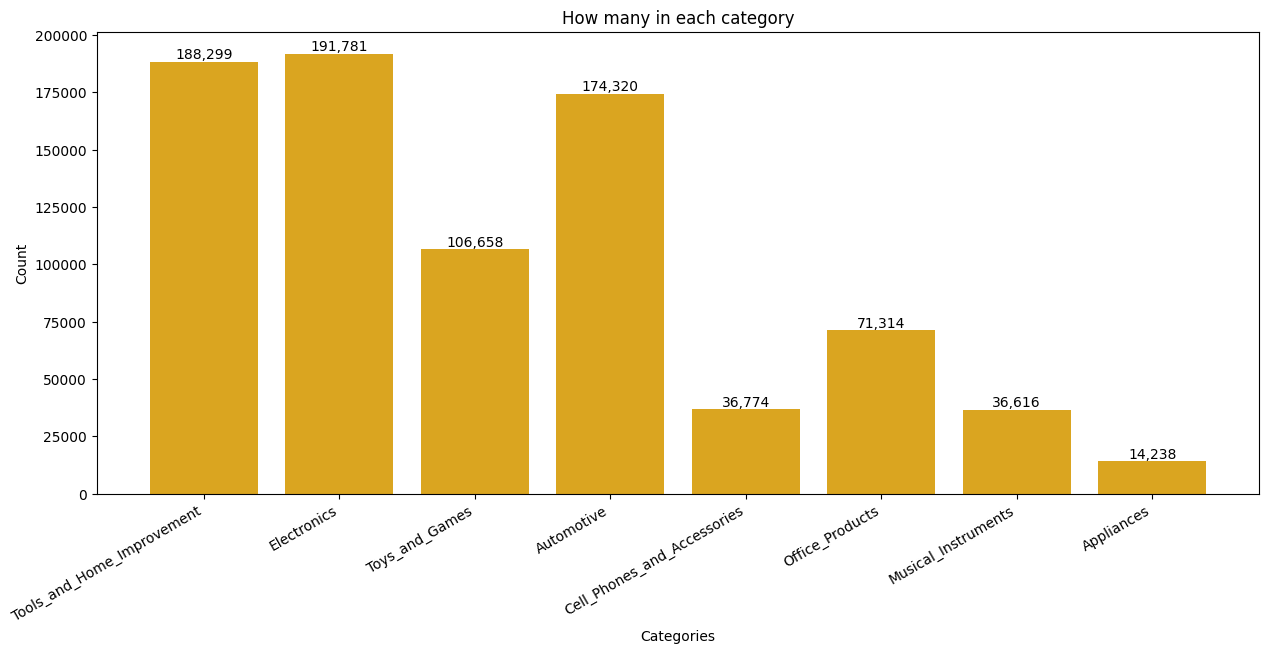

In [28]:
category_counts = Counter([item.category for item in sample])
categories = category_counts.keys()
counts = [category_counts[category] for category in categories]

plt.figure(figsize=(15, 6))
plt.bar(categories, counts, color="goldenrod")
plt.title('How many in each category')
plt.xlabel('Categories')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(counts):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')
plt.show()

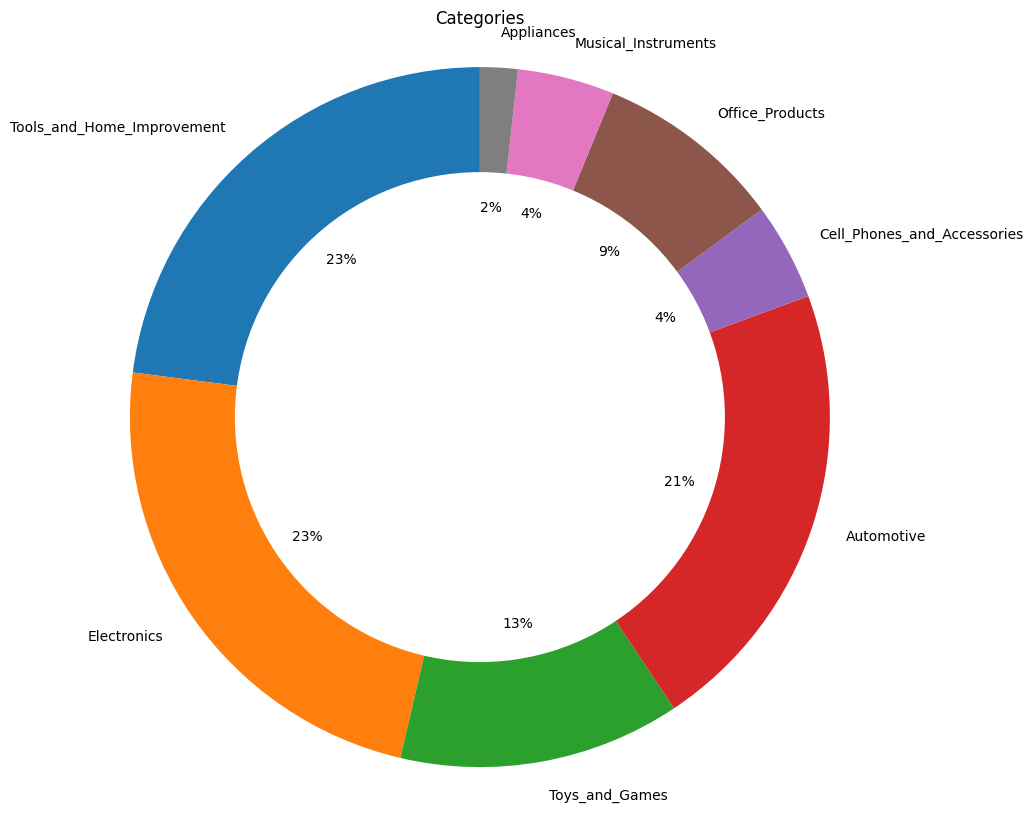

In [29]:
# For another perspective, a donut chart of category share
plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Categories')
plt.axis('equal')
plt.show()

### Any simple correlations?

Before reaching for ML, sanity-check whether price correlates with obvious features like text length or weight:

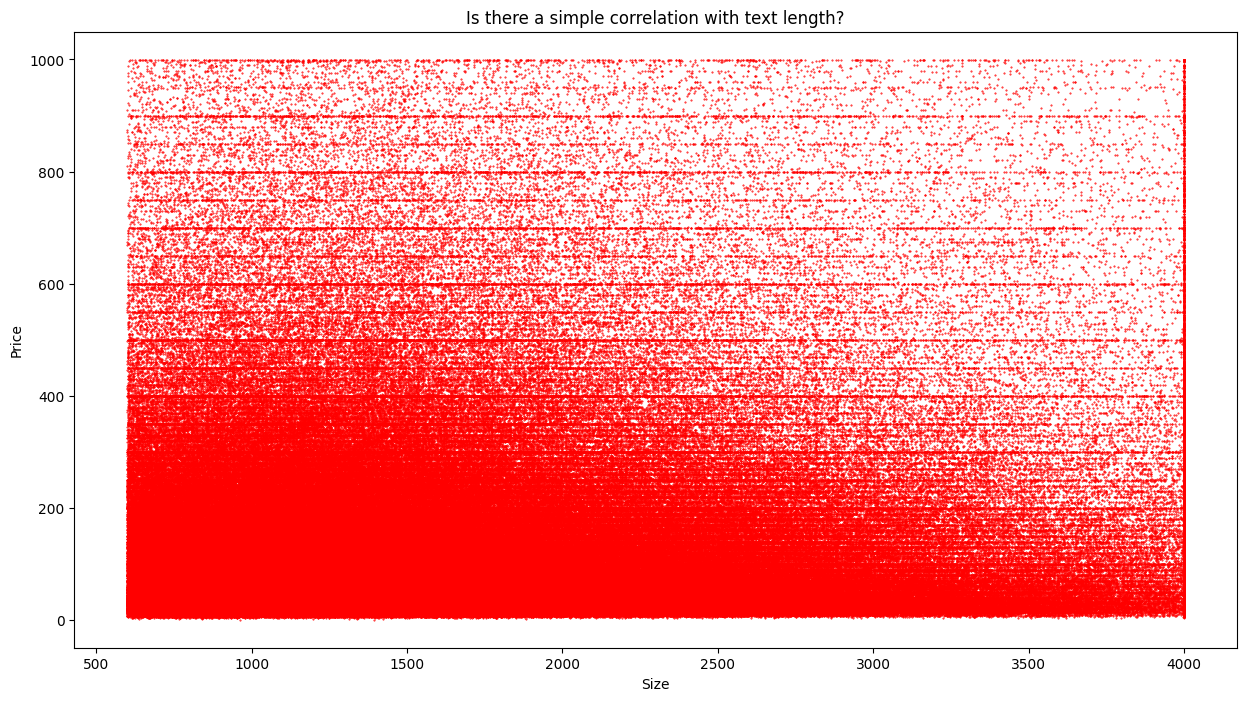

In [30]:
# How does the price vary with the character count?
sizes = [len(item.full) for item in sample]
prices = [item.price for item in sample]

plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation with text length?')
plt.show()

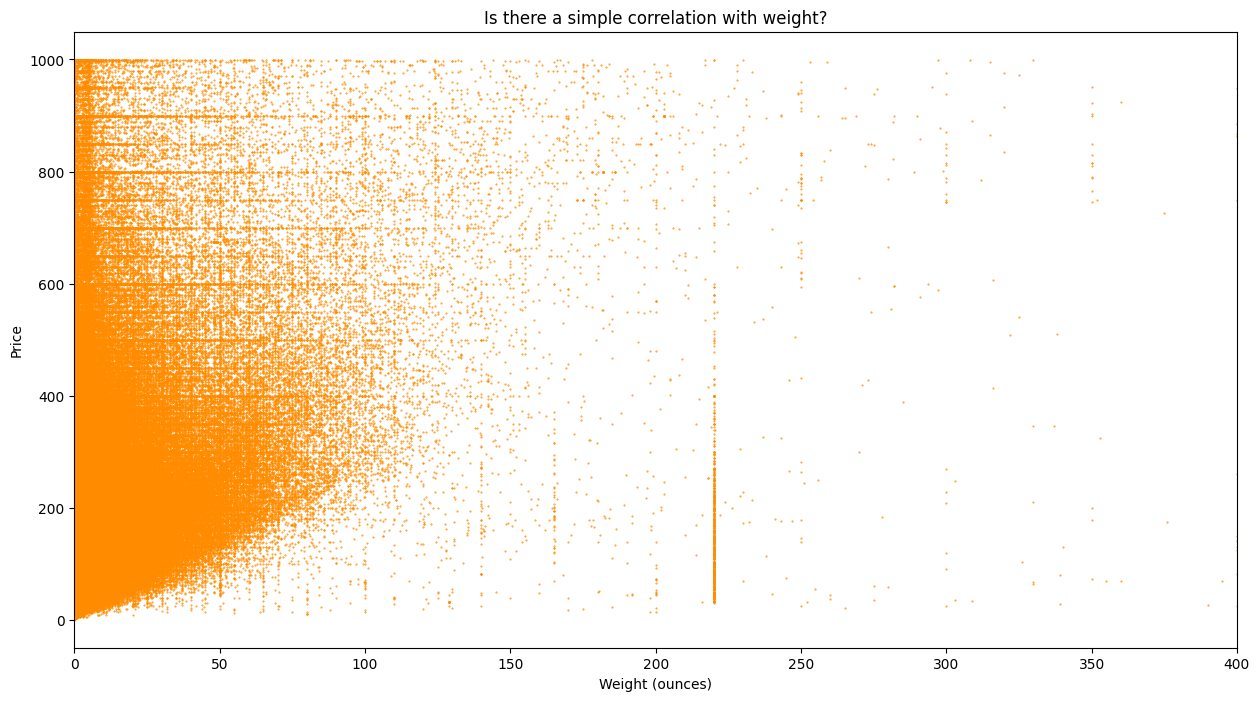

In [31]:
# How does the price vary with the weight?
ounces = [item.weight for item in sample]
prices = [item.price for item in sample]

plt.figure(figsize=(15, 8))
plt.scatter(ounces, prices, s=0.2, color="darkorange")
plt.xlabel('Weight (ounces)')
plt.ylabel('Price')
plt.xlim(0, 400)
plt.title('Is there a simple correlation with weight?')
plt.show()

## Push this dataset to the HuggingFace Hub

Replace `username` with **your** HuggingFace username to push your own curated copy.
Or skip this cell — you can load Ed's dataset on Day 2 instead.

We save two versions: a **full** dataset (800k train) and a **lite** dataset (20k train) for faster iteration.

In [32]:
username = "marcolerma"  # <-- replace with your HuggingFace username
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

train = sample[:800_000]
val = sample[800_000:810_000]
test = sample[810_000:]

Item.push_to_hub(full, train, val, test)

train_lite = train[:20_000]
val_lite = val[:1_000]
test_lite = test[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)

Uploading the dataset shards:   0%|          | 0/3 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Creating parquet from Arrow format:   0%|          | 0/5 [00:00<?, ?ba/s]

...

Setting num_proc from 1 back to 1 for the test split to disable multiprocessing as it only contains one shard.


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

## Sidenote

If you like matplotlib's named colors, bookmark this:
https://matplotlib.org/stable/gallery/color/named_colors.html